In [18]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.model_selection import train_test_split

RANDOM_STATE = 42
sns.set_theme(style="whitegrid", palette="colorblind")
np.random.seed(RANDOM_STATE)

print("Libraries loaded.")

Libraries loaded.


In [5]:
%pip install openpyxl

Note: you may need to restart the kernel to use updated packages.


In [5]:
import pandas as pd
df = pd.read_excel('../data/Data_Train.xlsx')
print("Shape:", df.shape)
df.head()

Shape: (10683, 11)


,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
0,IndiGo,24/03/2019,Banglore,New Delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,non-stop,No info,3897
1,Air India,1/05/2019,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2 stops,No info,7662
2,Jet Airways,9/06/2019,Delhi,Cochin,DEL → LKO → BOM → COK,09:25,04:25 10 Jun,19h,2 stops,No info,13882
3,IndiGo,12/05/2019,Kolkata,Banglore,CCU → NAG → BLR,18:05,23:30,5h 25m,1 stop,No info,6218
4,IndiGo,01/03/2019,Banglore,New Delhi,BLR → NAG → DEL,16:50,21:35,4h 45m,1 stop,No info,13302


In [7]:
print("Data types:\n")
print(df.dtypes)
print("\nMissing value counts:\n")
print(df.isnull().sum())
print("\nDuplicate rows:", df.duplicated().sum())
print("\nTarget (Price) summary statistics:\n")
print(df['Price'].describe())

Data types:

Airline              str
Date_of_Journey      str
Source               str
Destination          str
Route                str
Dep_Time             str
Arrival_Time         str
Duration             str
Total_Stops          str
Additional_Info      str
Price              int64
dtype: object

Missing value counts:

Airline            0
Date_of_Journey    0
Source             0
Destination        0
Route              1
Dep_Time           0
Arrival_Time       0
Duration           0
Total_Stops        1
Additional_Info    0
Price              0
dtype: int64

Duplicate rows: 220

Target (Price) summary statistics:

count    10683.000000
mean      9087.064121
std       4611.359167
min       1759.000000
25%       5277.000000
50%       8372.000000
75%      12373.000000
max      79512.000000
Name: Price, dtype: float64


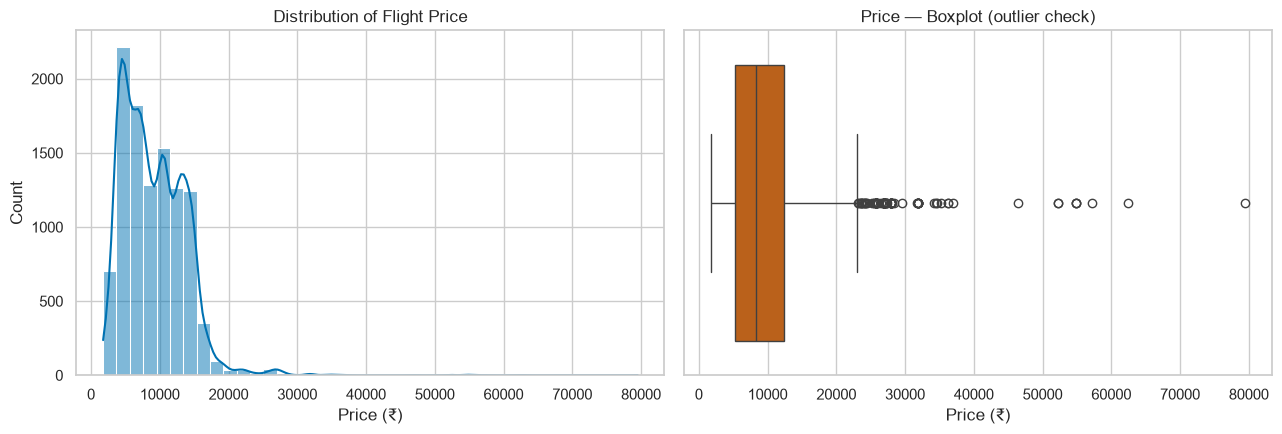

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
sns.histplot(df['Price'], bins=40, kde=True, ax=axes[0], color='#0072B2')
axes[0].set_title('Distribution of Flight Price')
axes[0].set_xlabel('Price (₹)')
axes[0].set_ylabel('Count')

sns.boxplot(x=df['Price'], ax=axes[1], color='#D55E00')
axes[1].set_title('Price — Boxplot (outlier check)')
axes[1].set_xlabel('Price (₹)')
plt.tight_layout()
plt.savefig('price_distribution.png', bbox_inches='tight', dpi=100)
plt.show()

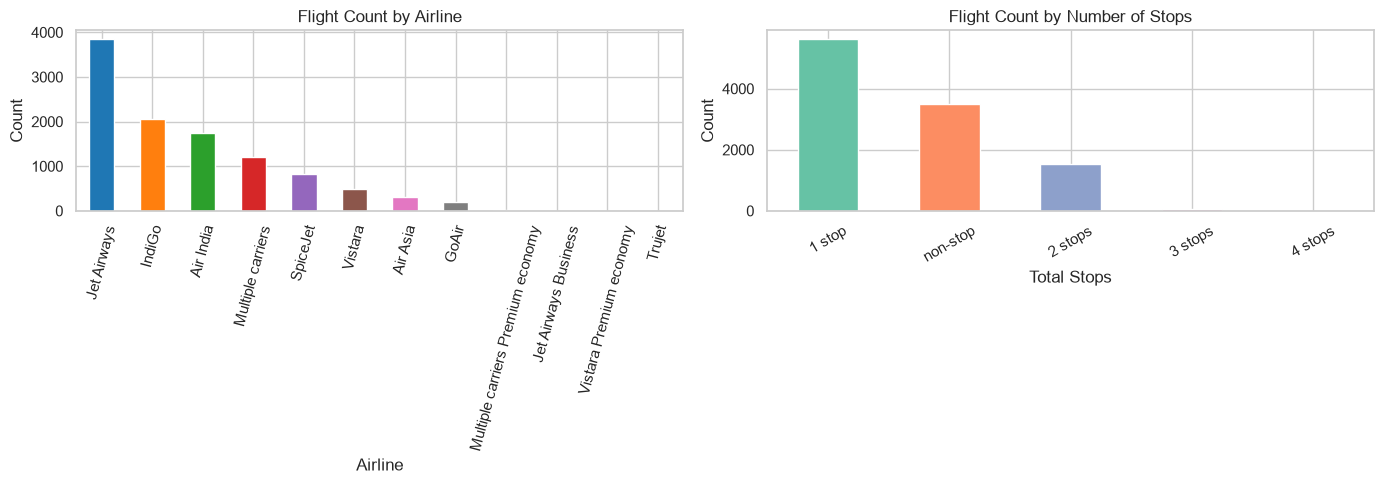

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
df['Airline'].value_counts().plot(kind='bar', ax=axes[0], color=sns.color_palette('tab10'))
axes[0].set_title('Flight Count by Airline')
axes[0].set_xlabel('Airline'); axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=75)

df['Total_Stops'].value_counts().plot(kind='bar', ax=axes[1], color=sns.color_palette('Set2'))
axes[1].set_title('Flight Count by Number of Stops')
axes[1].set_xlabel('Total Stops'); axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.savefig('categorical_distributions.png', bbox_inches='tight', dpi=100)
plt.show()

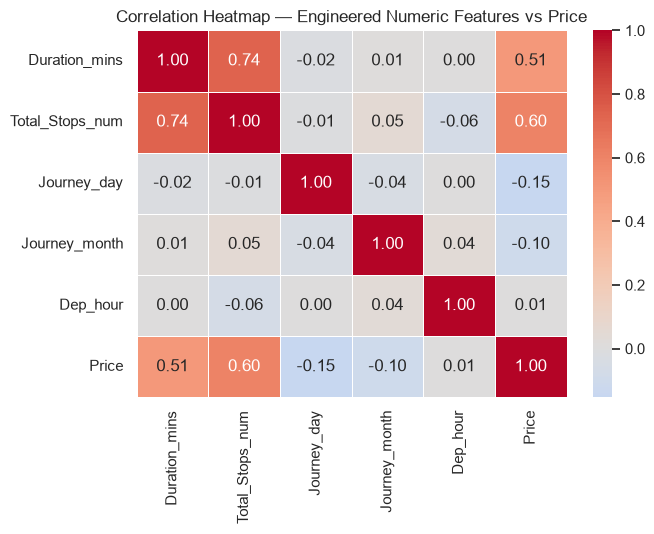

In [10]:
eda = df.copy()
eda['Duration_mins'] = eda['Duration'].str.replace('h', '*60').str.replace('m', '*1').str.replace(' ', '+').apply(lambda x: eval(x) if isinstance(x, str) else np.nan)
stop_map = {'non-stop': 0, '1 stop': 1, '2 stops': 2, '3 stops': 3, '4 stops': 4}
eda['Total_Stops_num'] = eda['Total_Stops'].map(stop_map)
eda['Journey_day'] = pd.to_datetime(eda['Date_of_Journey'], format='%d/%m/%Y').dt.day
eda['Journey_month'] = pd.to_datetime(eda['Date_of_Journey'], format='%d/%m/%Y').dt.month
eda['Dep_hour'] = pd.to_datetime(eda['Dep_Time'], format='%H:%M').dt.hour

corr_cols = ['Duration_mins', 'Total_Stops_num', 'Journey_day', 'Journey_month', 'Dep_hour', 'Price']
plt.figure(figsize=(7, 5.5))
sns.heatmap(eda[corr_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0, linewidths=0.5)
plt.title('Correlation Heatmap — Engineered Numeric Features vs Price')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', bbox_inches='tight', dpi=100)
plt.show()

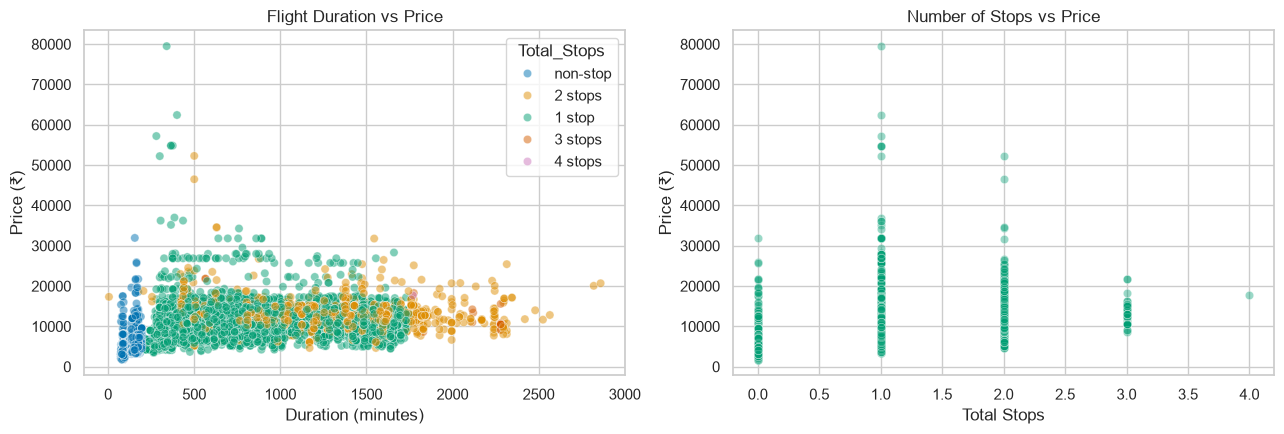

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
sns.scatterplot(data=eda, x='Duration_mins', y='Price', hue='Total_Stops', alpha=0.5, ax=axes[0], palette='colorblind')
axes[0].set_title('Flight Duration vs Price')
axes[0].set_xlabel('Duration (minutes)'); axes[0].set_ylabel('Price (₹)')

sns.scatterplot(data=eda, x='Total_Stops_num', y='Price', alpha=0.4, ax=axes[1], color='#009E73')
axes[1].set_title('Number of Stops vs Price')
axes[1].set_xlabel('Total Stops'); axes[1].set_ylabel('Price (₹)')
plt.tight_layout()
plt.savefig('scatter_feature_target.png', bbox_inches='tight', dpi=100)
plt.show()

In [15]:
df_clean = df.copy()

# Drop the single row with nulls (Route / Total_Stops) — negligible loss (1 / 10683 rows
df_clean = df_clean.dropna()

# Drop exact duplicate rows
before = len(df_clean)
df_clean = df_clean.drop_duplicates()
print(f"Dropped {before - len(df_clean)} duplicate rows -> {len(df_clean)} rows remain")

# Outlier check on Price using IQR
Q1, Q3 = df_clean['Price'].quantile([0.25, 0.75])
IQR = Q3 - Q1
lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
n_outliers = ((df_clean['Price'] < lower) | (df_clean['Price'] > upper)).sum()
print(f"IQR bounds: [{lower:.0f}, {upper:.0f}] -> {n_outliers} rows flagged as outliers ({n_outliers/len(df_clean)*100:.1f}%)")

# Strategy: cap (winsorize) rather than delete — these are genuine premium/business-class
# fares, not data errors, and dropping ~2% of rows would bias the model against expensive routes.
df_clean['Price'] = df_clean['Price'].clip(lower=lower, upper=upper)
print("Outliers capped at IQR bounds. New Price range:", df_clean['Price'].min(), "-", df_clean['Price'].max())

Dropped 220 duplicate rows -> 10462 rows remain
IQR bounds: [-5457, 23026] -> 94 rows flagged as outliers (0.9%)
Outliers capped at IQR bounds. New Price range: 1759.0 - 23025.875


In [16]:
# Duration -> total minutes (numeric)
def parse_duration(x):
    h, m = 0, 0
    parts = x.split()
    for p in parts:
        if 'h' in p:
            h = int(p.replace('h', ''))
        elif 'm' in p:
            m = int(p.replace('m', ''))
    return h * 60 + m

df_clean['Duration_mins'] = df_clean['Duration'].apply(parse_duration)

# Date_of_Journey -> day, month (year is constant/uninformative — 2019 only)
journey = pd.to_datetime(df_clean['Date_of_Journey'], format='%d/%m/%Y')
df_clean['Journey_day'] = journey.dt.day
df_clean['Journey_month'] = journey.dt.month

# Dep_Time / Arrival_Time -> hour, minute
dep = pd.to_datetime(df_clean['Dep_Time'], format='%H:%M')
df_clean['Dep_hour'] = dep.dt.hour
df_clean['Dep_min'] = dep.dt.minute

arr = pd.to_datetime(df_clean['Arrival_Time'].str.split(' ').str[0], format='%H:%M')
df_clean['Arrival_hour'] = arr.dt.hour
df_clean['Arrival_min'] = arr.dt.minute

# Total_Stops -> ordinal encoding (stops have a natural order 0 < 1 < 2 < 3 < 4)
stop_map = {'non-stop': 0, '1 stop': 1, '2 stops': 2, '3 stops': 3, '4 stops': 4}
df_clean['Total_Stops_num'] = df_clean['Total_Stops'].map(stop_map)

# Additional_Info: collapse rare categories (<1% frequency) into 'Other' to avoid
# creating one-hot columns that are almost entirely zero
info_counts = df_clean['Additional_Info'].value_counts(normalize=True)
rare_info = info_counts[info_counts < 0.01].index
df_clean['Additional_Info'] = df_clean['Additional_Info'].replace(rare_info, 'Other')

# Engineered flag: is this a red-eye / night departure? (Dep_hour before 6am or after 10pm)
# Justification: red-eye flights are frequently discounted, so this may help the model
# capture a pricing pattern that raw Dep_hour (treated linearly) would miss.
df_clean['Is_Night_Departure'] = ((df_clean['Dep_hour'] < 6) | (df_clean['Dep_hour'] >= 22)).astype(int)

# Drop columns we've now extracted information from, plus Route (high-cardinality,
# largely redundant with Source + Destination + Total_Stops)
df_clean = df_clean.drop(columns=['Date_of_Journey', 'Dep_Time', 'Arrival_Time', 'Duration', 'Route', 'Total_Stops'])

print(df_clean.shape)
df_clean.head()

(10462, 14)


,Airline,Source,Destination,Additional_Info,Price,Duration_mins,Journey_day,Journey_month,Dep_hour,Dep_min,Arrival_hour,Arrival_min,Total_Stops_num,Is_Night_Departure
0,IndiGo,Banglore,New Delhi,No info,3897.0,170,24,3,22,20,1,10,0,1
1,Air India,Kolkata,Banglore,No info,7662.0,445,1,5,5,50,13,15,2,1
2,Jet Airways,Delhi,Cochin,No info,13882.0,1140,9,6,9,25,4,25,2,0
3,IndiGo,Kolkata,Banglore,No info,6218.0,325,12,5,18,5,23,30,1,0
4,IndiGo,Banglore,New Delhi,No info,13302.0,285,1,3,16,50,21,35,1,0


In [19]:
TARGET = 'Price'
categorical_cols = ['Airline', 'Source', 'Destination', 'Additional_Info']
numeric_cols = ['Duration_mins', 'Journey_day', 'Journey_month', 'Dep_hour', 'Dep_min',
                 'Arrival_hour', 'Arrival_min', 'Total_Stops_num', 'Is_Night_Departure']

df_clean
X = df_clean[categorical_cols + numeric_cols]
y = df_clean[TARGET]

# Train/test split FIRST (80:20) — every encoder/scaler below is fit on X_train only,
# then applied to X_test, to avoid data leakage.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE)
print("Train:", X_train.shape, " Test:", X_test.shape)

# Shared preprocessing pipeline (ColumnTransformer): one-hot encode categoricals,
# standard-scale numerics. handle_unknown='ignore' guards against any category
# present in test but not train.
preprocessor = ColumnTransformer(transformers=[
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_cols),
    ('num', StandardScaler(), numeric_cols)
])

preprocessor.fit(X_train)                       # fit on TRAIN ONLY
X_train_proc = preprocessor.transform(X_train)  # transform train
X_test_proc = preprocessor.transform(X_test)    # transform test

feature_names = list(preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_cols)) + numeric_cols
print("Processed feature matrix shape:", X_train_proc.shape)

Train: (8369, 13)  Test: (2093, 13)
Processed feature matrix shape: (8369, 36)


In [8]:
from sklearn.tree import DecisionTreeRegressor

In [9]:
results = {}

def evaluate(name, model, X_tr, X_te):
    model.fit(X_tr, y_train)
    preds = model.predict(X_te)
    r2 = r2_score(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    mae = mean_absolute_error(y_test, preds)
    results[name] = {'model': model, 'preds': preds, 'R2': r2, 'RMSE': rmse, 'MAE': mae}
    print(f"{name:28s}  R2={r2:.4f}   RMSE={rmse:8.1f}   MAE={mae:8.1f}")
    return model

In [11]:
RANDOM_STATE = 42

In [20]:
# 6. Decision Tree Regressor — tune max_depth
dt = DecisionTreeRegressor(max_depth=8, random_state=RANDOM_STATE)
evaluate('Decision Tree Regressor', dt, X_train_proc, X_test_proc)

Decision Tree Regressor       R2=0.8491   RMSE=  1662.5   MAE=  1037.7


,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",8
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max

In [21]:
# 7. Random Forest Regressor — ensemble baseline
rf = RandomForestRegressor(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1)
evaluate('Random Forest Regressor', rf, X_train_proc, X_test_proc)

Random Forest Regressor       R2=0.9149   RMSE=  1248.6   MAE=   625.6


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"m

In [22]:
# 8. Gradient Boosting Regressor
gbr = GradientBoostingRegressor(n_estimators=200, learning_rate=0.1, max_depth=3, random_state=RANDOM_STATE)
evaluate('Gradient Boosting Regressor', gbr, X_train_proc, X_test_proc)

Gradient Boosting Regressor   R2=0.8620   RMSE=  1589.9   MAE=  1095.2


,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",200
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given to each Tree estimator at eachboosting iteration.In addition, it controls the random permutation of the features ateach split (see Notes for more details).It also controls the random splitting of the training data to obtain avalidation set if `n_iter_no_change` is not None.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"loss loss: {'squared_error', 'absolute_error', 'huber', 'quantile'}, default='squared_error'Loss function to be optimized. 'squared_error' refers to the squarederror for regression. 'absolute_error' refers to the absolute error ofregression and is a robust loss function. 'huber' is acombination of the two. 'quantile' allows quantile regression (use`alpha` to specify the quantile).See:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_quantile.py`for an example that demonstrates quantile regression for creatingprediction intervals with `loss='quantile'`.",'squared_error'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.",0.1
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'This parameter has no effect... versionadded:: 0.18.. deprecated:: 1.9 `criterion` is deprecated and will be removed in 1.11.",'deprecated'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf

In [23]:
# 9. Support Vector Regressor — features are already scaled via the ColumnTransformer above
svr = SVR(C=10, kernel='rbf')
evaluate('Support Vector Regressor', svr, X_train_proc, X_test_proc)

Support Vector Regressor      R2=0.3935   RMSE=  3333.3   MAE=  2439.3


,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive.The penalty is a squared l2. For an intuitive visualization of theeffects of scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",10
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm.If none is given, 'rbf' will be used. If a callable is given it isused to precompute the kernel matrix.For an intuitive visualization of different kernel typessee :ref:`sphx_glr_auto_examples_svm_plot_svm_regression.py`",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"epsilon epsilon: float, default=0.1Epsilon in the epsilon-SVR model. It specifies the epsilon-tubewithin which no penalty is associated in the training loss functionwith points predicted within a distance epsilon from the actualvalue. Must be non-negative.",0.1
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide <shrinking_svm>`.",True
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False
,"max_iter max_iter: int, default=-1Hard limit on iterations within solver, or -1 for no limit.",-1


In [24]:
# 10. K-Nearest Neighbors Regressor
knn = KNeighborsRegressor(n_neighbors=7)
evaluate('K-Nearest Neighbors Regressor', knn, X_train_proc, X_test_proc)

K-Nearest Neighbors Regressor  R2=0.8209   RMSE=  1811.4   MAE=  1106.6


,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",7
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Uniform weights are used by default.See the following example for a demonstration of the impact ofdifferent weighting schemes on predictions::ref:`sphx_glr_auto_examples_neighbors_plot_regression.py`.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this isequivalent to using manhattan_distance (l1), and euclidean_distance(l2) for p = 2. For arbitrary p, minkowski_distance (l_p) is used.",2
,"metric metric: str, DistanceMetric object or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance<https://docs.scipy.org/doc/scipy/reference/spatial.distance.html>`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.If metric is a DistanceMetric object, it will be passed directly tothe underlying computation routines.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.Doesn't affect :meth:`fit` method.",None
Name,Type,Value
"effective_metric_ effective_metric_: str or callableThe distance metric to use. It will be same as the `metric` parameteror a synonym of it, e.g. 'euclidean' if the `metric` parameter set to'minkowski' and `p` parameter set to 2.",str,'eu...an'
"effective_metric_params_ effective_metric_params_: dictAdditional keyword arguments for the metric function. For most metricswill be same with `metric_params` parameter, but may also contain the`p` parameter value if the `effective_metric_` attribute is set to'minkowski'.",dict,{}


In [26]:
summary = pd.DataFrame({
    name: {'R2': r['R2'], 'RMSE': r['RMSE'], 'MAE': r['MAE']}
    for name, r in results.items()
}).T.sort_values('R2', ascending=False)

summary.index.name = 'Algorithm'
summary

,R2,RMSE,MAE
Algorithm,,,
Random Forest Regressor,0.914904,1248.567909,625.577024
Gradient Boosting Regressor,0.862014,1589.922610,1095.162242
Decision Tree Regressor,0.849130,1662.493662,1037.749758
K-Nearest Neighbors Regressor,0.820894,1811.396347,1106.611784
Support Vector Regressor,0.393507,3333.278726,2439.320267


In [27]:
# Decision Tree — GridSearchCV over max_depth / min_samples_split
dt_grid = {'max_depth': [4, 6, 8, 10, 12, None], 'min_samples_split': [2, 5, 10]}
dt_search = GridSearchCV(DecisionTreeRegressor(random_state=RANDOM_STATE), dt_grid,
                          cv=5, scoring='r2', n_jobs=-1)
dt_search.fit(X_train_proc, y_train)

dt_tuned = dt_search.best_estimator_
dt_tuned_preds = dt_tuned.predict(X_test_proc)
dt_tuned_r2 = r2_score(y_test, dt_tuned_preds)

print("Best params:", dt_search.best_params_)
print(f"Decision Tree R2:  before tuning = {results['Decision Tree Regressor']['R2']:.4f}  "
      f"-> after tuning = {dt_tuned_r2:.4f}  (Δ = {dt_tuned_r2 - results['Decision Tree Regressor']['R2']:+.4f})")

Best params: {'max_depth': None, 'min_samples_split': 10}
Decision Tree R2:  before tuning = 0.8491  -> after tuning = 0.8724  (Δ = +0.0233)


In [28]:
# Random Forest — RandomizedSearchCV over n_estimators / max_depth / max_features
rf_grid = {
    'n_estimators': [100, 200, 300, 400],
    'max_depth': [None, 10, 15, 20, 25],
    'max_features': ['sqrt', 'log2', None],
    'min_samples_split': [2, 5, 10]
}
rf_search = RandomizedSearchCV(RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1),
                                rf_grid, n_iter=15, cv=5, scoring='r2',
                                random_state=RANDOM_STATE, n_jobs=-1)
rf_search.fit(X_train_proc, y_train)

rf_tuned = rf_search.best_estimator_
rf_tuned_preds = rf_tuned.predict(X_test_proc)
rf_tuned_r2 = r2_score(y_test, rf_tuned_preds)

print("Best params:", rf_search.best_params_)
print(f"Random Forest R2:  before tuning = {results['Random Forest Regressor']['R2']:.4f}  "
      f"-> after tuning = {rf_tuned_r2:.4f}  (Δ = {rf_tuned_r2 - results['Random Forest Regressor']['R2']:+.4f})")

# Update results with tuned model / predictions for downstream plots
results['Random Forest Regressor']['model'] = rf_tuned
results['Random Forest Regressor']['preds'] = rf_tuned_preds
results['Random Forest Regressor']['R2'] = rf_tuned_r2

Best params: {'n_estimators': 100, 'min_samples_split': 2, 'max_features': None, 'max_depth': None}
Random Forest R2:  before tuning = 0.9149  -> after tuning = 0.9152  (Δ = +0.0003)


In [29]:
top2 = summary.sort_values('R2', ascending=False).head(2).index.tolist()
print("Top 2 models (this member's section):", top2)

for name in top2:
    model = results[name]['model']
    cv_scores = cross_val_score(model, X_train_proc, y_train, cv=5, scoring='r2', n_jobs=-1)
    print(f"{name:28s}  5-fold CV R2 = {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")

Top 2 models (this member's section): ['Random Forest Regressor', 'Gradient Boosting Regressor']
Random Forest Regressor       5-fold CV R2 = 0.9161 (+/- 0.0061)
Gradient Boosting Regressor   5-fold CV R2 = 0.8601 (+/- 0.0057)


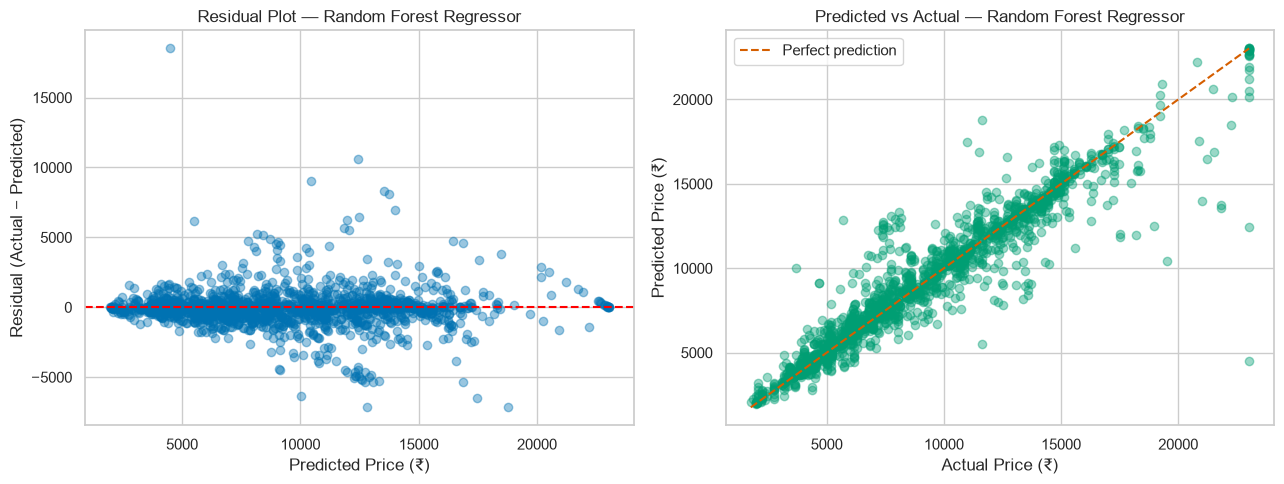

In [30]:
best_name = summary.sort_values('R2', ascending=False).index[0]
best_preds = results[best_name]['preds']

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

residuals = y_test.values - best_preds
axes[0].scatter(best_preds, residuals, alpha=0.4, color='#0072B2')
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set_title(f'Residual Plot — {best_name}')
axes[0].set_xlabel('Predicted Price (₹)'); axes[0].set_ylabel('Residual (Actual − Predicted)')

axes[1].scatter(y_test, best_preds, alpha=0.4, color='#009E73')
lims = [min(y_test.min(), best_preds.min()), max(y_test.max(), best_preds.max())]
axes[1].plot(lims, lims, 'r--', label='Perfect prediction')
axes[1].set_title(f'Predicted vs Actual — {best_name}')
axes[1].set_xlabel('Actual Price (₹)'); axes[1].set_ylabel('Predicted Price (₹)')
axes[1].legend()

plt.tight_layout()
plt.savefig('residual_predicted_vs_actual.png', bbox_inches='tight', dpi=100)
plt.show()

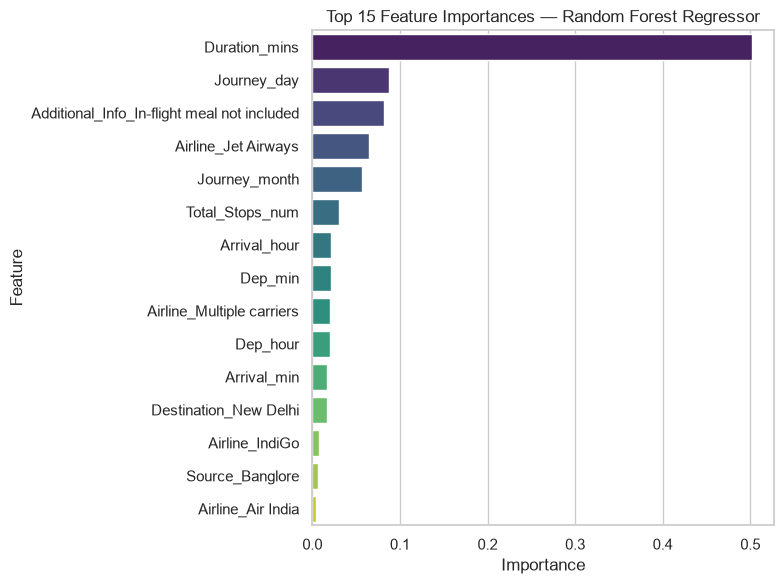

In [31]:
tree_model = results['Random Forest Regressor']['model']
importances = pd.Series(tree_model.feature_importances_, index=feature_names).sort_values(ascending=False).head(15)

plt.figure(figsize=(8, 6))
sns.barplot(x=importances.values, y=importances.index, palette='viridis')
plt.title('Top 15 Feature Importances — Random Forest Regressor')
plt.xlabel('Importance'); plt.ylabel('Feature')
plt.tight_layout()
plt.savefig('feature_importance.png', bbox_inches='tight', dpi=100)
plt.show()